In [1]:
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

In [6]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    api_key=api_key,
    base_url="https://api.groq.com/openai/v1",
    model="groq/compound"
)

In [7]:
from langgraph.graph import MessagesState
from langchain_core.messages import HumanMessage, SystemMessage

sys_msg = SystemMessage(content="You are a helpful assistant to respond to general inquiries.")

# Node as assistant - A python method with messagestate as input argument
def assistant(state: MessagesState): 
    history = state["messages"]
    assistant_msg = llm.invoke([sys_msg] + history)
    return {"messages": history + [assistant_msg]}

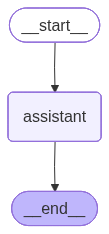

In [4]:
from langgraph.graph import START, StateGraph, END
from IPython.display import Image, display

builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant)

#Define Edge - Sequence
builder.add_edge(START, "assistant")
builder.add_edge("assistant", END)

react_graph = builder.compile()

display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))

In [8]:
messages = [HumanMessage(content="What is the capital of India?")]
messages = react_graph.invoke({"messages": messages})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is the capital of India?
================================== Ai Message ==================================

The capital of India is **New Delhi**.
